
<html>
<body>




<p align="center">
<img src="https://ensias.um5.ac.ma/sites/ensias.um5.ac.ma/files/logo5_0.jpg" alt="logo ensias" width="120" height="140"/></p>

<p align="center"><b><font size="5">Tutorial: Régression linéaire simple </font></b></p>
<p align="center"><b><font size="5" color="gray">(Méthode des moindres carrés avec sckit-learn) </font></b></p>


---


<br>
<font size="2">
<b>Élément de module :</b>	Machine learning<br>	
<b>Année universitaire :</b>	2020-2027<br>
<b>Semestre :</b>	
</font>		


---

<font size="2">
<I>Pr. Aissam BERRAHOU</I></font>
<br>
<br>


</body>
</html>


<font size="2">
La régression a pour objectif d’expliquer une variable Y par une autre variable X. Par exemple on peut expliquer les performances d’un athlète par la durée de son entrainement ou même  le salaire d’une personne par le nombre d’années passées à l’université. Dans notre cas on s’intéresse à la régression linéaire multiple qui modélise la relation entre X(ensembles de variables explicatives) et Y par une équation linéaire.
</font>

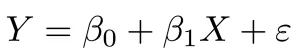


**Traitements réalisés** :<br>
<font size="2">
* Création d'une base de données
* Splitting de la base de données
* Visualisation de la base de donnée
* Recherche des paramètres du modèle(appliquer la méthode des moindres carrés)
* Evaluation du modèle par la méthode d'analyse de la variance(Ensemble de test)
</font>


# <font color="red" size="4"><b>1. Création d'une base de données</font>


In [2]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt


In [3]:
n_observations=50
x,y=make_regression(n_samples=n_observations,n_features=1, noise=10)
y=y.reshape(n_observations,1)
print(np.shape(x))
print(y.shape)

(50, 1)
(50, 1)


 <font color="blue" size="3">a. Spiliting de la base de données en deux sous-ensembles(Apprentissage et Test)</font>

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

 <font color="blue" size="3">b. Visualisation des deux sous-ensembles(Apprentissage et Test)</font>

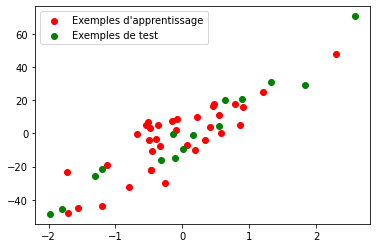

In [5]:
plt.scatter(x_train,y_train, c='r',label="Exemples d'apprentissage")
plt.scatter(x_test,y_test, c='green',label='Exemples de test')
plt.legend()

# <font color="red" size="4"><b>2. Recherche des paramètres du modèle avec sckitlearn</font>

## <font color="blue" size="3">a. instanciation d'un modèle de régression linéaire</font>

In [12]:
from sklearn.linear_model import LinearRegression,SGDRegressor
model= LinearRegression()
#model=SGDRegressor(eta0=0.005,max_iter=2000) méthode de descente de gradient



## <font color="blue" size="3">b. Apprentissage du modèle </font>

In [13]:
model.fit(x_train,y_train)

betaEstimer=[[model.coef_[0,0]],[model.intercept_[0]]]

print("les paramètres du modèle:",betaEstimer)

les paramètres du modèle: [[20.672267833049176], [-0.8355795153400405]]


## <font color="blue" size="3">b. Visualisation du modèle de régression</font>

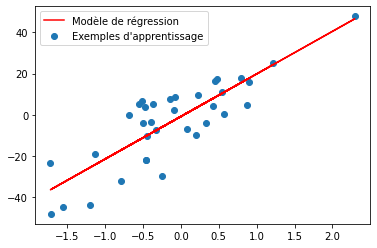

In [9]:
y_pred=model.predict(x_train)
plt.scatter(x_train,y_train,label="Exemples d'apprentissage")
plt.plot(x_train,y_pred,c='r',label="Modèle de régression")
plt.legend()

# <font color="red" size="4"><b>6. Evaluation du modèle sur l'ensemble de test par la méthode d'analyse de la variance </font>

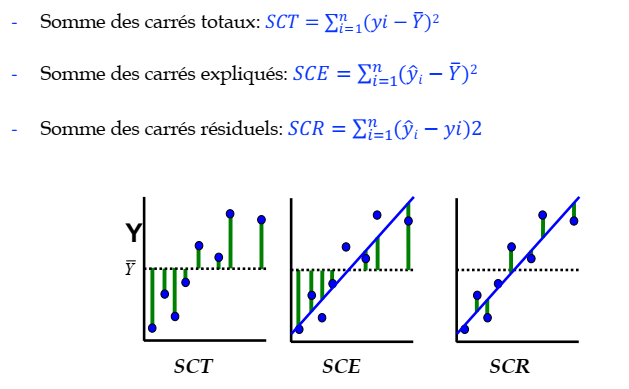

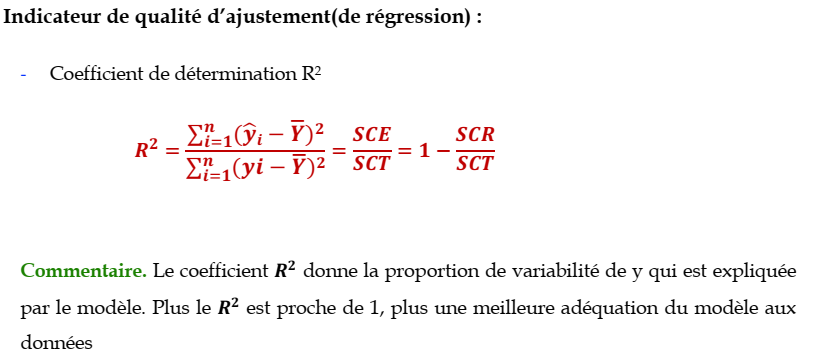

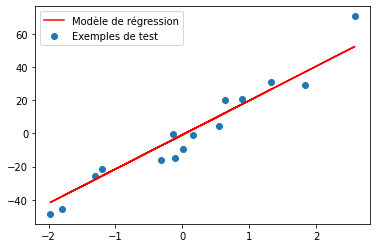

In [10]:
y_pred_t=model.predict(x_test)
plt.scatter(x_test,y_test,label="Exemples de test")
plt.plot(x_test,y_pred_t,c='r',label="Modèle de régression")
plt.legend()

In [11]:

def coefficient_determination(y,y_pr):
  SCT=((y-y.mean())**2).sum()
  SCR=((y_pr-y)**2).sum()

  return 1- (SCR/SCT)

coefficient_determination(y_test,y_pred_t)


0.9304225108492662